In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración visual
sns.set_theme(style="whitegrid")

# Unidad 6 - Ajustes y modelos 2

```{admonition} 📂 Descargar archivos  
[Descargar los archivos para la práctica desde el Campus Virtual](https://campusv.fceia.unr.edu.ar/course/view.php?id=471)
```
### **Ejercicio N°1**

El dataset `student_data.csv` contiene información sobre el promedio de horas semanales de estudio que un conjunto de estudiantes dedicó para la preparación de un examen y la calificación final recibida luego de rendirlo.

1. Realice un gráfico que le permita visualizar la relación existente entre las calificaciones finales y las horas de estudio del grupo de estudiantes. 
    
    ¿Cómo describiría dicha relación a partir de lo observado? 
    
    ¿Qué métrica utilizaría para cuantificar el grado de asociación lineal entre ambas variables? Calcúlela e interprete el valor obtenido.
    
2. A partir de los datos, ajuste un modelo de regresión lineal para la calificación final del examen en función de las horas semanales de estudio. Represente gráficamente el modelo ajustado en el gráfico realizado en el ítem 1.
3. Escriba el modelo ajustado en forma desarrollada e interprete cada uno de los coeficientes que lo componen.

In [3]:
estudiantes=pd.read_csv('./Datasets Práctica Nº 6/Parte_2/student_data.csv')
estudiantes.drop(columns='Unnamed: 0',inplace=True)

<Axes: xlabel='hours_studied', ylabel='exam_scores'>

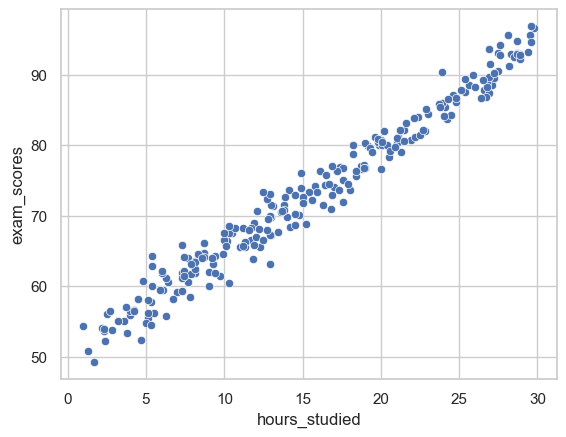

In [4]:
sns.scatterplot(x='hours_studied',y='exam_scores',data=estudiantes)

Text(0.5, 1.0, 'Horas de Estudio vs Calificación')

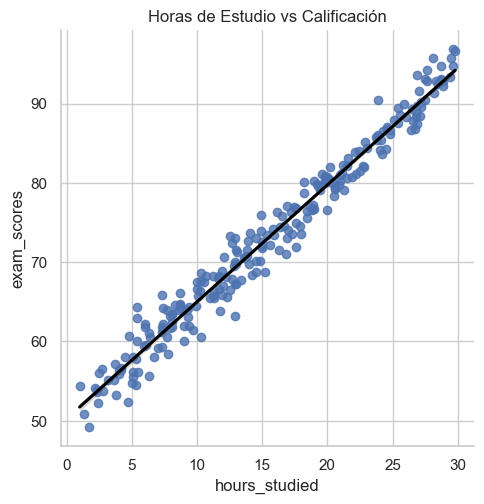

In [5]:
sns.lmplot(x='hours_studied',y='exam_scores',data=estudiantes,line_kws={'color':'black'})
plt.title("Horas de Estudio vs Calificación")

In [6]:
correlacion=estudiantes['hours_studied'].corr(estudiantes['exam_scores'])
print(f'La correlacion entre horas estudiadas y calificaciones es {round(correlacion,3)} ')

La correlacion entre horas estudiadas y calificaciones es 0.986 


In [7]:
modelo = smf.ols(formula = 'exam_scores ~ hours_studied', data = estudiantes).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:            exam_scores   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.972
Method:                 Least Squares   F-statistic:                     8555.
Date:                Sat, 06 Jun 2026   Prob (F-statistic):          2.11e-191
Time:                        17:57:48   Log-Likelihood:                -512.26
No. Observations:                 245   AIC:                             1029.
Df Residuals:                     243   BIC:                             1036.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        50.2541      0.278    180.576

$\hat{y}= 50.2541+1.4750*x$

si no estudian se sacan 50.254 y a medida que estudien es mas probable que aprueben

--------------------------------------

### **Ejercicio N°2**

Supongamos que ajustamos un modelo de regresión lineal por mínimos cuadrados para el precio de una propiedad en moneda local (\$, peso local) en función de los siguientes predictores: superficie en metros cuadrados ($x_1$), cantidad de habitaciones ($x_2$), antigüedad en años ($x_3$), y ubicación ($x_4$, codificada de la siguiente manera: 0 para ámbito urbano y 1 para suburbano). Obtenemos los siguientes coeficientes:

- $\hat{\beta_0} = 10000$
- $\hat{\beta_1} = 5000$
- $\hat{\beta_2} = 2000$
- $\hat{\beta_3} = -1500$
- $\hat{\beta_4} = - 15000$
1. Escriba la ecuación del modelo ajustado en forma desarrollada.
2. A partir del modelo ajustado, ¿cuál de las siguientes afirmaciones es correcta y por qué?
    1. Para un mismo número de habitaciones, antigüedad y metros cuadrados, las propiedades en áreas suburbanas son más caras, en promedio, que las que se encuentran en áreas urbanas.
    2. Para viviendas ubicadas en el área urbana con una misma antigüedad y superficie, el precio predicho por el modelo se incrementa, en promedio, en $10000 por cada año de antigüedad.
    3. El número de habitaciones es una variable que tiene “más peso” sobre el precio de la propiedad en viviendas en áreas urbanas que en aquellas que se encuentran en áreas suburbanas.
    4. El modelo predice que una propiedad ubicada en el área urbana cuesta $15000 más que una propiedad de la misma superficie, antigüedad y cantidad de habitaciones que se encuentre en el área suburbana.


---------------------------------
La ecuacion seria la siguiente:

$\hat{y}= 10000+5000*x1+2000*x2-1500*x3-15000*x4$

* La 1 es FALSA porque si es subrubana es $15000 mas barato que una urbana
* La 2 es FALSA porque decrece $1500 por cada año de antiguedad
* La 3 es FALSA porque el area donde este no influye en el precio segun la cantidad de habitaciones. Por cada habitacion este donde este siempre se incrementa $2000 su precio
* La 4 es VERDADERA porque si es suburbana b4 es -15000 osea hace que sea $15000 mas barata que una urbana 
-------------------------------------

### **Ejercicio N°3**

El dataset `penguins` es un conjunto de datos sobre pingüinos de tres especies diferentes que anidan en una colonia de Archipiélago Palmer, en la Antártida. Contiene información sobre las medidas corporales de los pingüinos, incluyendo la longitud y profundidad del pico (`bill_length_mm` y `bill_depth_mm` , respectivamente), la longitud de la aleta (`flipper_length_mm`) y la masa corporal (`body_mass_g`), así como información sobre el sexo.

In [8]:
pinguino=pd.read_csv('./Datasets Práctica Nº 6/Parte_2/penguins.csv')
pinguino.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 344 non-null    int64  
 1   species            344 non-null    object 
 2   island             344 non-null    object 
 3   bill_length_mm     342 non-null    float64
 4   bill_depth_mm      342 non-null    float64
 5   flipper_length_mm  342 non-null    float64
 6   body_mass_g        342 non-null    float64
 7   sex                333 non-null    object 
 8   year               344 non-null    int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 24.3+ KB


* 1. Realice un gráfico que le permita visualizar la relación que existe entre la longitud del pico y la longitud de la aleta de los pingüinos Palmer, según la especie. ¿Qué observa?

Text(0.5, 1.0, 'Largo de pico vs largo de aleta segun especie')

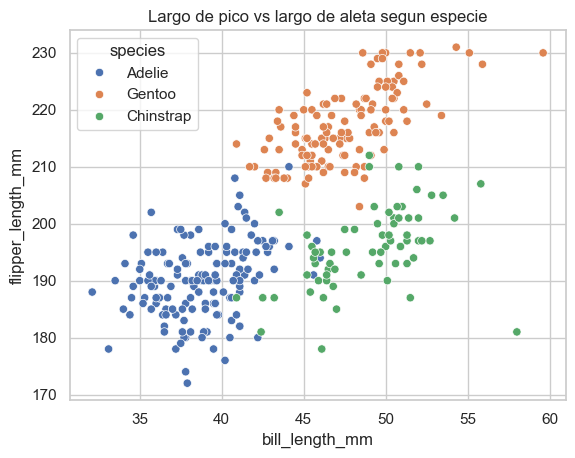

In [9]:
sns.scatterplot(data=pinguino,x='bill_length_mm',y='flipper_length_mm',hue='species')
plt.title('Largo de pico vs largo de aleta segun especie')

* 2. Ajuste un modelo de regresión lineal que le permita predecir la longitud promedio del pico de los pingüinos Palmer a partir de la longitud de la aleta (**modelo 1**).

In [10]:
modelo=smf.ols('bill_length_mm ~ flipper_length_mm', data=pinguino).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:         bill_length_mm   R-squared:                       0.431
Model:                            OLS   Adj. R-squared:                  0.429
Method:                 Least Squares   F-statistic:                     257.1
Date:                Sat, 06 Jun 2026   Prob (F-statistic):           1.74e-43
Time:                        17:57:48   Log-Likelihood:                -968.98
No. Observations:                 342   AIC:                             1942.
Df Residuals:                     340   BIC:                             1950.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -7.2649      3.20

La ecuacion segun el modelo de regresion lineal es:

$\hat{y}= -7.2649+0.2548*x$


* 3. A partir de las observaciones que realizó en el ítem 1, introduzca alguna modificación sobre el modelo inicial que le permita mejorar su capacidad predictiva para la longitud del pico de los pingüinos. 
Ajuste el nuevo modelo propuesto (**modelo 2**). 

In [11]:
pinguino['female_dummy'] = pinguino['sex'].apply(lambda x: 1 if x == 'Female' else 0)

In [12]:
#quedarnos solo con los female
pd.get_dummies(pinguino['sex']).drop('male',axis=1)

,female
0,False
1,True
2,True
3,False
4,True
...,...
339,False
340,True
341,False
342,False


In [13]:
modelo2=smf.ols("bill_length_mm ~ flipper_length_mm + species + body_mass_g + sex + bill_depth_mm", data=pinguino).fit()
print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:         bill_length_mm   R-squared:                       0.839
Model:                            OLS   Adj. R-squared:                  0.836
Method:                 Least Squares   F-statistic:                     282.3
Date:                Sat, 06 Jun 2026   Prob (F-statistic):          7.50e-126
Time:                        17:57:48   Log-Likelihood:                -734.13
No. Observations:                 333   AIC:                             1482.
Df Residuals:                     326   BIC:                             1509.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               15.0166 

* 4. ¿Cuál de los dos modelos (**modelo 1, modelo 2**) proporciona un mejor ajuste? ¿Qué métrica utilizó para compararlos?


La ecuacion segun el modelo de regresion lineal es:

$\hat{y}= 15.0166+9.5655*x1+6.4044*x2+2.0297*x3+0.0686*x4+0.0011*x5+0.313*x6$ 

* x1=1 x2=0 si es Chinstrap
* x1=0 x2=1 si es Gentoo
* x1=0 x2=0 si es Adelie
* x3=1 si es macho, x3=0 si es hembra

Es mejor estre modelo porque tiene un $R^2=0.834$ mucho mas alto que el primer modelo ($R^2=0.429$)

* 5. Utilice el modelo seleccionado en el ítem anterior para predecir la longitud de pico que tendrá un pingüino Chinstrap de 17.6 mm de profundidad de pico, 191 mm de longitud de aleta, 3125 g de masa corporal y sexo masculino.

In [14]:
prediccion=15.0166+9.5655*1+6.4044*0+2.0297*1+0.0686*191+0.0011*3125+0.313*17.6
print(f'La prediccion del pinguino es {round(prediccion,2)}')

La prediccion del pinguino es 48.66


--------------------------------------

### **Ejercicio N°4**

Utilizando el dataset `dataset_rendimiento.csv`, que contiene información sobre 235 estudiantes universitarios de segundo año de una institución universitaria en relación a las horas semanales promedio de estudio dedicadas, el tipo de desayuno que consumen antes de los exámenes y el rendimiento medio en los exámenes parciales:


In [15]:
students=pd.read_csv('./Datasets Práctica Nº 6/Parte_2/dataset_rendimiento.csv')
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Horas_de_Estudio  235 non-null    int64  
 1   Desayuno          235 non-null    object 
 2   Rendimiento       235 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 5.6+ KB


In [16]:
students.columns.tolist()

['Horas_de_Estudio', 'Desayuno', 'Rendimiento']

In [23]:
students['Desayuno'].value_counts()

Desayuno
Ninguno      89
Regular      75
Saludable    71
Name: count, dtype: int64

1. Ajuste un modelo de regresión lineal que permita predecir el rendimiento promedio de estudiantes de segundo año a partir del número de horas semanales promedio de estudio y el tipo de desayuno que consumen. 

In [25]:
modelo_estudiantes=smf.ols(' Rendimiento ~ Horas_de_Estudio + Desayuno ',data=students).fit()
print(modelo_estudiantes.summary())

                            OLS Regression Results                            
Dep. Variable:            Rendimiento   R-squared:                       0.386
Model:                            OLS   Adj. R-squared:                  0.378
Method:                 Least Squares   F-statistic:                     48.47
Date:               sá., 06 jun. 2026   Prob (F-statistic):           2.46e-24
Time:                        18:19:30   Log-Likelihood:                -880.27
No. Observations:                 235   AIC:                             1769.
Df Residuals:                     231   BIC:                             1782.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                62.26

2. ¿Cuál/es de las variables incluidas contribuye/n significativamente a explicar el rendimiento de los estudiantes? Justifique.

el desayuno regular se podria descartar ya que el p-valor es mayor a 0.05, pero sin descartar la ecuacion lineal es:

* $\hat{y}=62.2677-1.0045*x_1-3.7436*x_2+1.985*x_3$

3. Utilizando el modelo ajustado, prediga el rendimiento promedio que presentará un estudiante que dedica, en promedio, 5.5 horas semanales de estudio y posee la costumbre de consumir un desayuno saludable previo a las instancias de examen.

* $\hat{y}=62.2677-1.0045*0-3.7436*1+1.985*5.5$

In [26]:
predicho=62.2677-1.0045*0-3.7436*1+1.985*5.5
print(f'El rendimiento predicho segun el modelo para el estudiante es: {round(predicho,2)}')

El rendimiento predicho segun el modelo para el estudiante es: 69.44


----------------------------------------------------------

### **Ejercicio N°5**

Un cliente lo contrató como científico de datos para que estudie la posible asociación entre la inversión en publicidad que realiza su empresa y las ventas de un producto particular. El conjunto de datos de publicidad `advertising.csv` contiene información acerca de las ventas de ese producto en 200 mercados diferentes, junto con presupuestos publicitarios para el producto para tres medios diferentes: televisión, radio y periódicos/diarios.

In [27]:
publicidad=pd.read_csv('./Datasets Práctica Nº 6/Parte_2/advertising.csv')
publicidad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [28]:
publicidad

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


1. ¿El presupuesto publicitario invertido en qué medio de comunicación se encuentra más fuertemente asociado con mayores ventas del producto?

In [37]:
round(publicidad.corr(),4)

,TV,Radio,Newspaper,Sales
TV,1.0000,0.0548,0.0566,0.9012
Radio,0.0548,1.0000,0.3541,0.3496
Newspaper,0.0566,0.3541,1.0000,0.1580
Sales,0.9012,0.3496,0.1580,1.0000


In [36]:
round(publicidad.corr()['Sales'].sort_values(ascending=False),3)

Sales        1.000
TV           0.901
Radio        0.350
Newspaper    0.158
Name: Sales, dtype: float64

* Se encuentra mas asociado con la publicidad en TV que en radio y diarios

2. Ajuste un modelo de regresión lineal que permita predecir las ventas promedio del producto en cuestión en función de los presupuestos publicitarios destinados a TV, radio y periódicos. En función de los resultados obtenidos, realice las modificaciones que considere adecuadas para quedarse con el mejor modelo ajustado y justifique cada decisión que tome.

In [39]:
mod_publi=smf.ols(' Sales ~ TV + Radio + Newspaper',data=publicidad).fit()
print(mod_publi.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     605.4
Date:               sá., 06 jun. 2026   Prob (F-statistic):           8.13e-99
Time:                        18:36:27   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             774.7
Df Residuals:                     196   BIC:                             787.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.6251      0.308     15.041      0.0

----------------------------------------------------------

* Basado en el p-value podemos descartar la variable de Diarios

In [40]:
mod_publi2=smf.ols(' Sales ~ TV + Radio ',data=publicidad).fit()
print(mod_publi2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     912.7
Date:               sá., 06 jun. 2026   Prob (F-statistic):          2.39e-100
Time:                        19:15:38   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             772.7
Df Residuals:                     197   BIC:                             782.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.6309      0.290     15.952      0.0

3. Escriba la ecuación del modelo ajustado en forma desarrollada e interprete el coeficiente correspondiente a la variable `TV`.

* $\hat{y}= 4.6309+0.0544*x_t+0.1072*x_r$

por cada mil dolares invertidos en publicidad de TV aumenta 0.0544 las ventas

4. Realice un gráfico para representar la distribución de los residuos del modelo y comente brevemente las características de la misma. ¿Podría suponerse que se cumple el supuesto de normalidad?

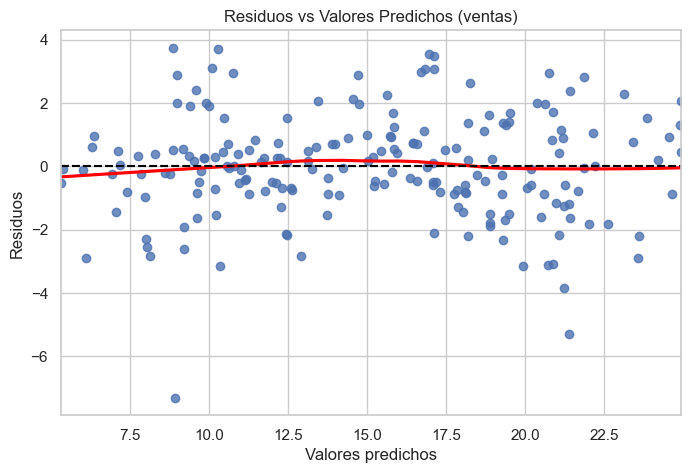

In [101]:
plt.figure(figsize=(8,5))
sns.residplot(x=mod_publi2.fittedvalues, y=mod_publi2.resid, lowess=True, line_kws={'color': 'red'})
plt.title("Residuos vs Valores Predichos (ventas)")
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Valores predichos')
plt.ylabel('Residuos')
plt.show()

* Si ves que los puntos forman una parábola (una curva en "U" o "U invertida"), significa que la relación real de tus datos era curva y tu modelo lineal está mal diseñado.

* Si la nube empieza muy estrecha y se va abriendo a medida que avanza el eje X (formando una silueta de megáfono o abanico), significa que tu modelo es muy preciso prediciendo valores pequeños, pero se vuelve caótico e impreciso con valores altos.

* Homocedasticidad: La altura de la nube de puntos debe mantenerse aproximadamente igual a lo largo de todo el eje X.

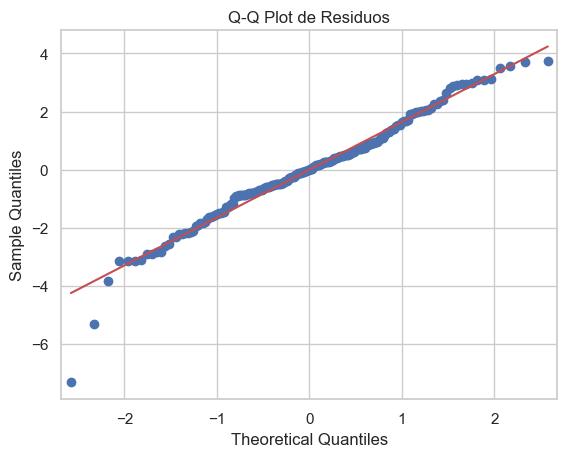

In [42]:
# Normalidad de Residuos
sm.qqplot(mod_publi2.resid, line='s')
plt.title("Q-Q Plot de Residuos")
plt.show()

* Los puntos se encuentran alineados sobre la diagonal, entonces cumplen con el supuesto de normalidad. 

* Si los extremos se curvaran, significa que tus datos tienen colas más pesadas o ligeras que una distribución normal

---------------------------------------

### **Ejercicio N°6**

El dataset `auto.xlsx` contiene información sobre 392 autos de distintas marcas y modelos. Entre las características registradas se encuentran: el consumo en millas por galón (`mpg`), caballos de fuerza (`horsepower`), peso en libras (`weight`) y la marca y el modelo (`name`).

In [43]:
autos=pd.read_excel('./Datasets Práctica Nº 6/Parte_2/auto.xlsx')
autos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
 8   name          392 non-null    object 
dtypes: float64(3), int64(5), object(1)
memory usage: 27.7+ KB


In [44]:
autos

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
387,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
388,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
389,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
390,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


1. ¿Qué porcentaje de los autos del dataset pertenecen a la marca **Ford**?

In [49]:
porcentaje_ford=autos['name'].str.contains('ford').sum()*100/len(autos)
print(f'El porcentaje de autos ford es {round(porcentaje_ford,2)}%')

El porcentaje de autos ford es 12.24%


2. Realice un gráfico que le permita visualizar la distribución de los autos del dataset en función de su origen. Para ello, tenga en cuenta que dicha información se encuentra en la columna `origin`, codificada de la siguiente manera: 1= americano, 2 = europeo y 3 = japonés.

C:\Users\Dark7 120gb\AppData\Local\Temp\ipykernel_23308\704431537.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=autos, x='origin_name', palette="Set1")


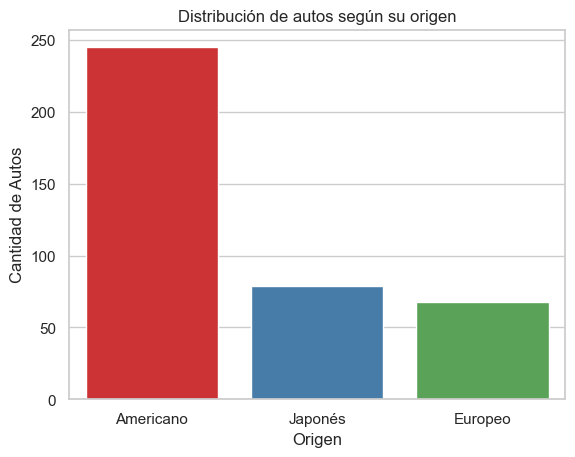

In [59]:
# Mapeamos los códigos numéricos a los nombres correctos
mapa_origen = {1: 'Americano', 2: 'Europeo', 3: 'Japonés'}
autos['origin_name'] = autos['origin'].map(mapa_origen)

sns.countplot(data=autos, x='origin_name', palette="Set1")
plt.title('Distribución de autos según su origen')
plt.xlabel('Origen')
plt.ylabel('Cantidad de Autos')
plt.show()

3. Ajuste un modelo de regresión lineal simple considerando al consumo del vehículo como la variable respuesta y a los caballos de fuerza como único predictor. En base a los resultados obtenidos responda:
    1. ¿La relación entre la variable respuesta y la explicativa es positiva o negativa?
    2. ¿Cómo interpreta el valor del coeficiente correspondiente a la variable `horsepower`?
    3. ¿Qué porcentaje de la variabilidad en el consumo de los vehículos es explicada por el modelo de regresión que ajustó?


In [61]:
modelo_autos=smf.ols(' mpg ~ horsepower', data=autos).fit()
print(modelo_autos.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:               sá., 06 jun. 2026   Prob (F-statistic):           7.03e-81
Time:                        19:43:59   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     39.9359      0.717     55.660      0.0

* La relacion lineal es negativa. A mayor caballos de fuerza mas consumo entonces hace menos millas por galon de nafta.
* Por cada unidad de horsepower, disminuye en 0.1578 las millas recorridas por galon de nafta
* El modelo explica el 60.6% de la variabilidad del consumo. Este valor corresponde al estadístico R-cuadrado $R^2=0.606$

4. Realice un gráfico para visualizar la relación que existe entre las variables `mpg` y `horsepower` en el dataset y represente sobre el mismo el ajuste realizado en el ítem anterior.  ¿Encuentra alguna falencia o limitación en el modelo propuesto? Justifique

<Figure size 800x600 with 0 Axes>

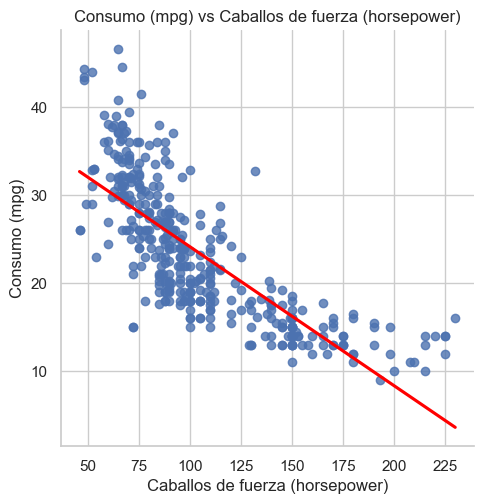

In [70]:
plt.figure(figsize=(8, 6))
sns.lmplot(data=autos,x='horsepower',y='mpg', line_kws={'color':'red'},ci=None)
plt.title('Consumo (mpg) vs Caballos de fuerza (horsepower)')
plt.xlabel('Caballos de fuerza (horsepower)')
plt.ylabel('Consumo (mpg)')
plt.show()

5. Si su respuesta al ítem fue afirmativa, ¿cómo podría mejorar el modelo para resolver las limitaciones o falencias encontradas?
* Con el resid plot se observa que forman una curva por lo tanto un modelo lineal no es el adecuado

----------------------------------------------------------

### **Ejercicio N°7**

El dataset `USA_Housing.xlsx` contiene la siguiente información sobre un conjunto de 5000 viviendas en Estados Unidos:

- **avg_area_income:** ingreso promedio de los residentes de la ciudad en la que se encuentra la vivienda.
- **avg_area_house_age:** antigüedad promedio de las casas que se encuentran en la misma ciudad en la que se encuentra la vivienda.
- **avg_area_number_of_rooms:** número promedio de ambientes en las casas que se encuentran en la misma ciudad en la que se encuentra la vivienda.
- **avg_area_number_of_bedrooms:** número promedio de habitaciones en las casas que se encuentran en la misma ciudad de la vivienda.
- **area_population:** población de la ciudad de la vivienda.
- **price:** precio de venta de la vivienda.
- **address:** domicilio de la vivienda.

In [71]:
casas=pd.read_excel('./Datasets Práctica Nº 6/Parte_2/USA_Housing.xlsx')
casas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   avg_area_income              5000 non-null   float64
 1   avg_area_house_age           5000 non-null   float64
 2   avg_area_number_of_rooms     5000 non-null   float64
 3   avg_area_number_of_bedrooms  5000 non-null   float64
 4   area_population              5000 non-null   float64
 5   price                        5000 non-null   float64
 6   address                      5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [72]:
casas

,avg_area_income,avg_area_house_age,avg_area_number_of_rooms,avg_area_number_of_bedrooms,area_population,price,address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386
...,...,...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06,USNS Williams\nFPO AP 30153-7653
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06,"PSC 9258, Box 8489\nAPO AA 42991-3352"
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06,"4215 Tracy Garden Suite 076\nJoshualand, VA 01..."
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06,USS Wallace\nFPO AE 73316


**PARTE I - Análisis exploratorio**

1. Importe el dataset al entorno de trabajo y realice cualquier tarea de limpieza y adecuación del mismo que considere necesaria para su posterior análisis.
2. Realice un gráfico que le permita visualizar la distribución del precio de venta de las residencias que componen el dataset. En base al gráfico realizado, ¿cómo describiría la distribución de la variable en cuanto a sus características de simetría?

In [74]:
casas.columns.str.strip()

Index(['avg_area_income', 'avg_area_house_age', 'avg_area_number_of_rooms',
       'avg_area_number_of_bedrooms', 'area_population', 'price', 'address'],
      dtype='object')

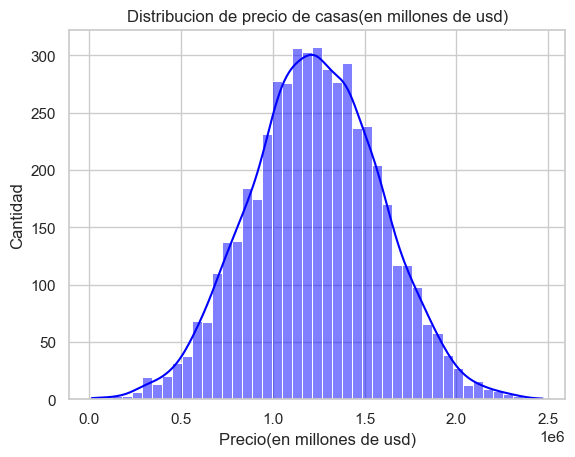

In [83]:
sns.histplot(data=casas,x='price',kde=True, color='blue')
plt.title('Distribucion de precio de casas(en millones de usd)')
plt.xlabel('Precio(en millones de usd)')
plt.ylabel('Cantidad')
plt.show()

In [80]:
#sns.kdeplot(data=casas,x='price')

3. Construya un gráfico que le permita evaluar el grado de asociación lineal que existe entre las distintas variables cuantitativas que componen el dataset. En base al mismo, identifique la/s variable/s que se encuentran más fuertemente correlacionadas e informe e interprete la medida de asociación lineal correspondiente.

In [90]:
#dropeo address
casas2=casas.drop(columns='address')

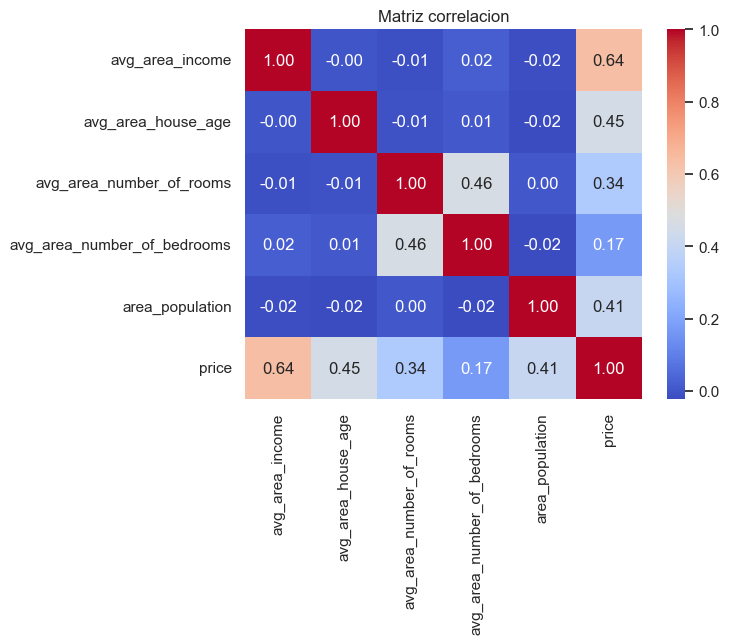

In [89]:
sns.heatmap(data=casas2.corr(),annot=True, cmap='coolwarm',fmt='.2f')
plt.title('Matriz correlacion')
plt.show()

4. Elija uno de los pares de variables que identificó en el ítem anterior y realice un gráfico que le permita visualizar la relación general que existe entre las mismas.

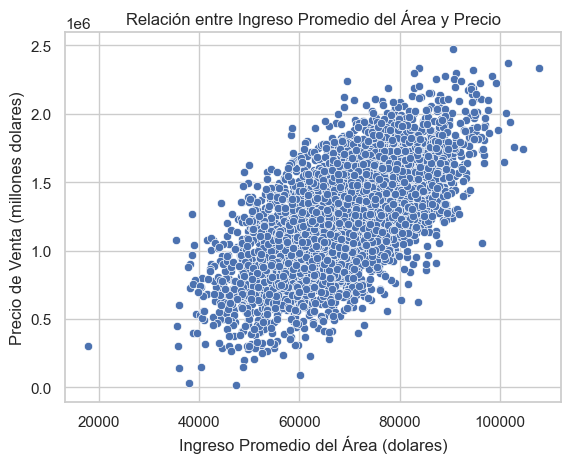

In [93]:
sns.scatterplot(data=casas,x='avg_area_income',y='price')
plt.title('Relación entre Ingreso Promedio del Área y Precio')
plt.xlabel('Ingreso Promedio del Área (dolares)')
plt.ylabel('Precio de Venta (millones dolares)')
plt.show()

**PARTE II - Ajuste de modelo**

El objetivo principal de esta segunda parte es analizar si es factible ajustar un modelo de regresión lineal que permita predecir el precio de venta de una vivienda en Estados Unidos a partir de la cantidad de personas que viven en la ciudad en la que ésta se ubica y su ingreso promedio, así como las características generales de las viviendas en dicho lugar (antigüedad promedio/número promedio de ambientes/número de habitaciones promedio).

1. Comience ajustando el modelo completo, incluyendo la totalidad de las variables explicativas o independientes que resultan de interés. ¿Cuál/es de las variables incluidas contribuye/n significativamente a explicar la calidad de los vinos? Justifique.

In [95]:
modelo_casas=smf.ols(' price ~ avg_area_income + avg_area_house_age + avg_area_number_of_rooms + avg_area_number_of_bedrooms + area_population',data=casas).fit()
print(modelo_casas.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.918
Method:                 Least Squares   F-statistic:                 1.119e+04
Date:               sá., 06 jun. 2026   Prob (F-statistic):               0.00
Time:                        20:08:31   Log-Likelihood:                -64714.
No. Observations:                5000   AIC:                         1.294e+05
Df Residuals:                    4994   BIC:                         1.295e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

* Todas las variables a excepcion de avg_area_number_of_bedrooms que tiene un p-value>0.05 son significativas

2. Ajuste un nuevo modelo tomando en cuenta su respuesta a la pregunta anterior. 
- En base al ajuste realizado, escriba dicho modelo en forma desarrollada e interprete cada uno de los coeficientes.
- ¿Qué medida utilizaría para comparar los dos modelos en cuanto a su bondad de ajuste? Interprete dicha medida para el modelo final.
- Realice un gráfico de valores predichos vs. valores reales y comente lo observado.

In [96]:
modelo2_casas=smf.ols(' price ~ avg_area_income + avg_area_house_age + avg_area_number_of_rooms + area_population',data=casas).fit()
print(modelo2_casas.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.918
Method:                 Least Squares   F-statistic:                 1.398e+04
Date:               sá., 06 jun. 2026   Prob (F-statistic):               0.00
Time:                        20:09:46   Log-Likelihood:                -64714.
No. Observations:                5000   AIC:                         1.294e+05
Df Residuals:                    4995   BIC:                         1.295e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

$\hat{y}-2638000+21.58*x_i+165700*x_a+121600*x_r+15.1961*x_p$

* el $B_o$ no tiene mucho sentido analizar
* el $B_1$ depende del ingreso del area, por cada $1 de ingreso aumenta en $21,58 el precio de una casa
* el $B_2$ depende de la antiguedad promedio de las casas de la zona, por cada año adicional de antiguedad promedio de las casas del area se aumenta en $165.700 el precio de una casa
* el $B_3$ depende del numero promedio de habitaciones de las casas de la zona, por cada habitacion extra se aumenta en $121.600 el precio de una casa
* el $B_4$ depende de la poblacion de la zona, por cada habitante adicional se aumenta en $15,19 el precio de una casa

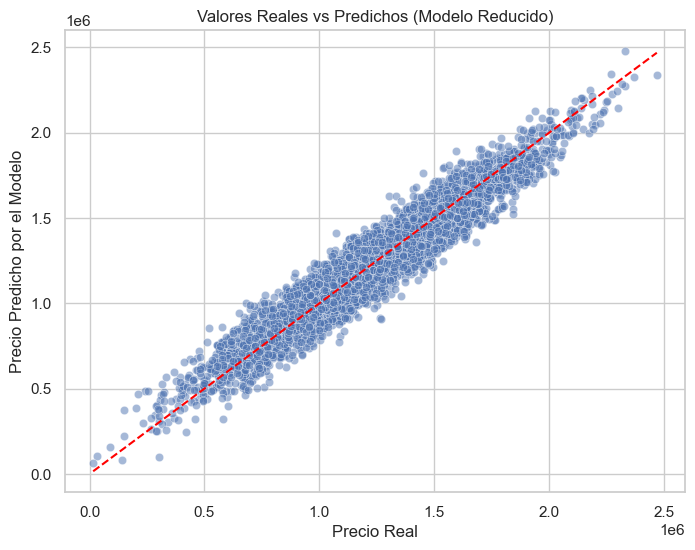

In [115]:
X_reduced = casas[['avg_area_income', 'avg_area_house_age', 
                'avg_area_number_of_rooms', 'area_population']]
X_reduced_sm = sm.add_constant(X_reduced)

y = casas['price']
y_pred = modelo2_casas.predict(X_reduced_sm)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y, y=y_pred, alpha=0.5)
# Línea ideal a 45 grados
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.title('Valores Reales vs Predichos (Modelo Reducido)')
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho por el Modelo')
plt.show()